In [117]:
from spiderwarp.optimized_steane_perm_state_prep import mqt_steane_opt
from spiderwarp.utils import _layer_cnot_circuit
from spiderwarp.csscode import CSSCode
from spiderwarp.layer_circuit import make_stim_circ_noisy

import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


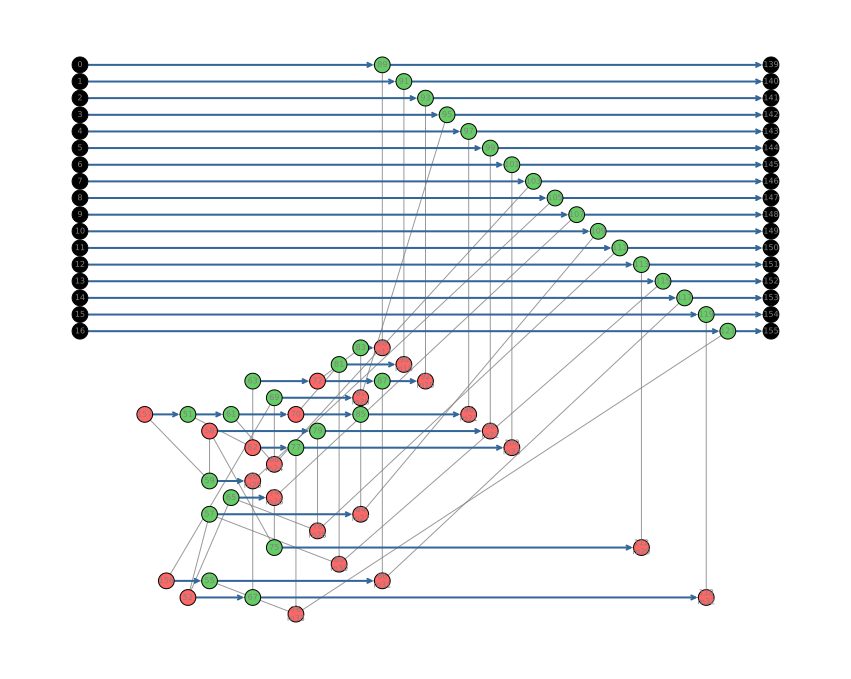

Optimised C_4: 34 -> 26


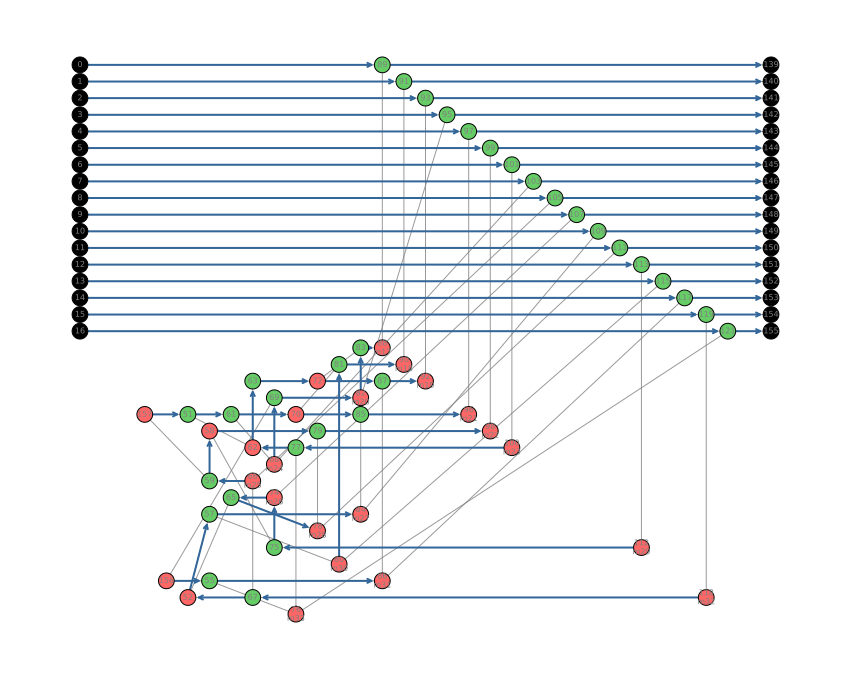

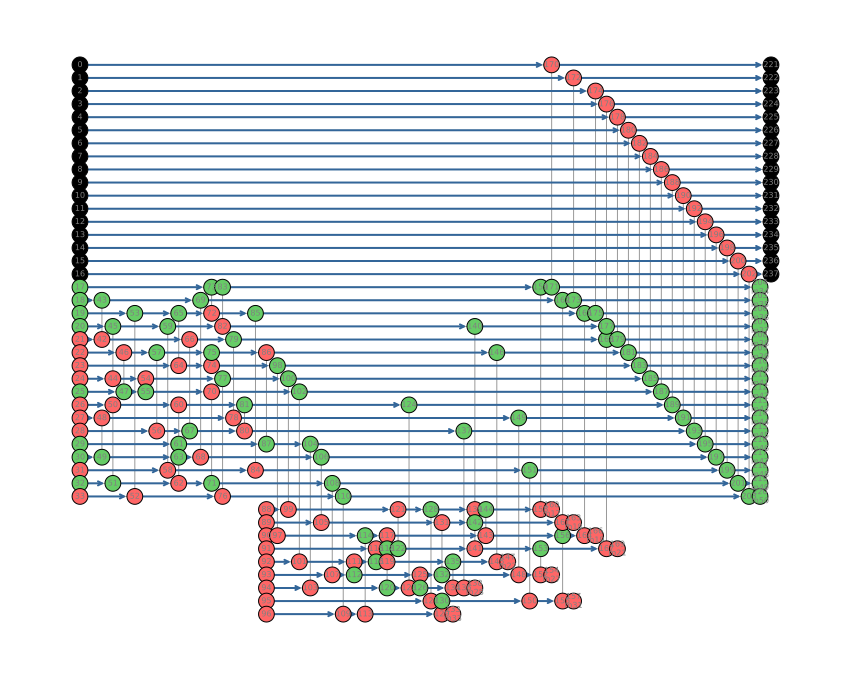

Optimised C_3; C_4:60 -> 36


In [157]:
code_name = "17_1_5"
code = CSSCode.load_code("MQT", code_name)
og_circ, circ, M = mqt_steane_opt(code_name, optimise_c2=False)

Num qubits: 51


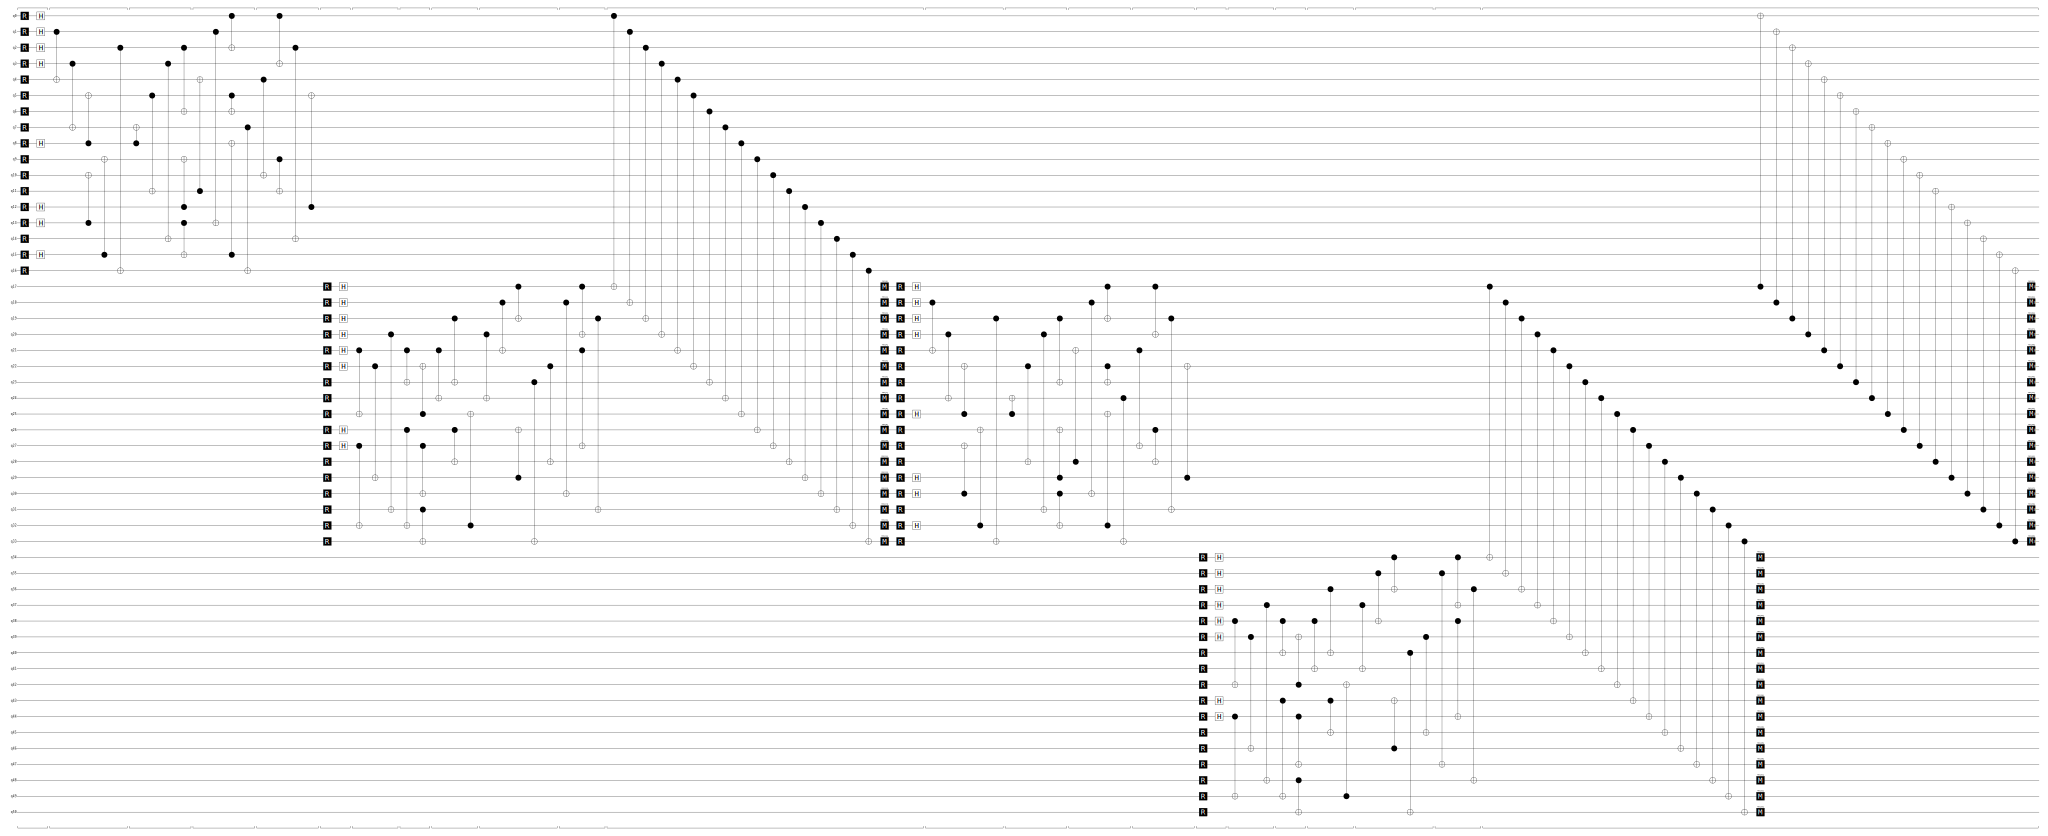

In [158]:
print("Num qubits:", og_circ.num_qubits)
og_circ.diagram('timeline-svg')

Num qubits: 36


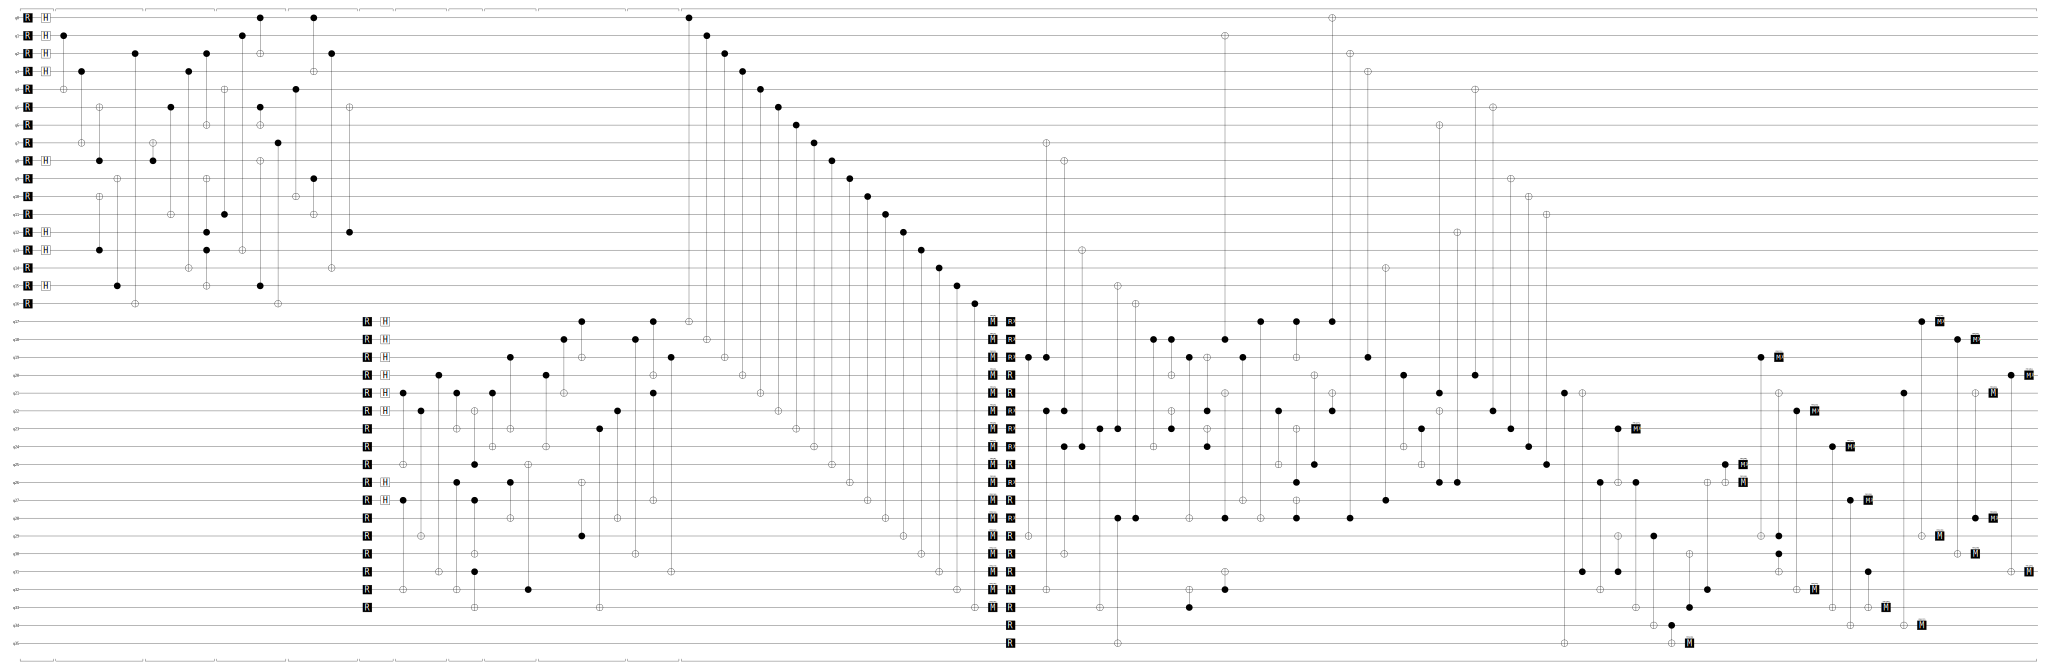

In [159]:
print("Num qubits:", circ.num_qubits)
circ.diagram('timeline-svg')

In [146]:
raw_cnots = [l for (name, l, _) in circ.flattened_operations() if name == "CX"]
cnots = [(ops[i], ops[i + 1]) for ops in raw_cnots for i in range(0, len(ops), 2)]
print("Num CX:", len(cnots))
print("Num qubits:", circ.num_qubits)
layered_cnots = _layer_cnot_circuit(cnots)
print("Depth:", len(layered_cnots))
print("MM", M)

Num CX: 120
Num qubits: 36
Depth: 28
MM {0: 16, 1: 11, 2: 5, 3: 10, 4: 14, 5: 0, 6: 1, 7: 2, 8: 4, 9: 43, 10: 33, 11: 28, 12: 45, 13: 37, 14: 22, 15: 39, 16: 44, 17: 48, 18: 27, 19: 31, 20: 17, 21: 34, 22: 18, 23: 35, 24: 19, 25: 36, 26: 21, 27: 38}


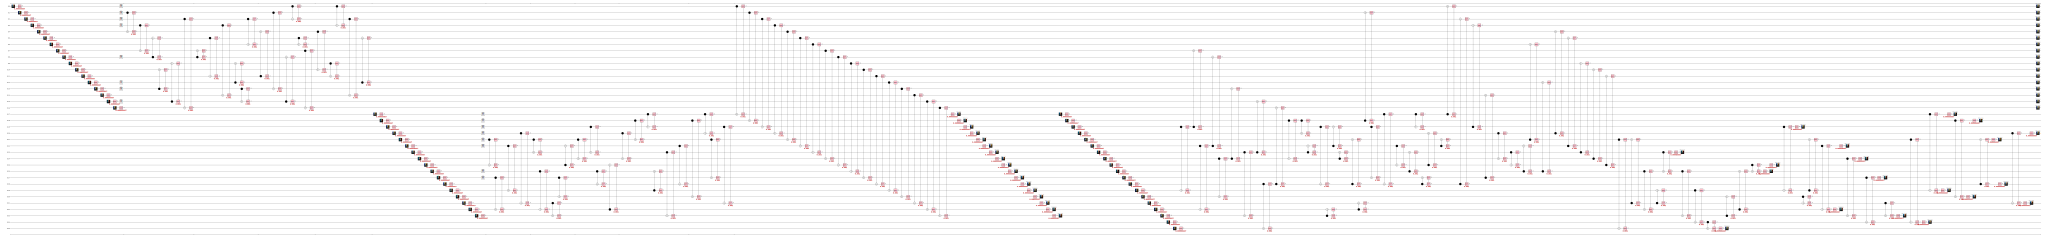

In [160]:
noisy_circ = make_stim_circ_noisy(circ, 0.001)
noisy_circ.append("M", range(code.H_x.shape[1]))
noisy_circ.diagram('timeline-svg')

In [161]:
smplr = noisy_circ.compile_sampler()
samples = smplr.sample(10_000_000)
raw_syndrome_measurements = samples[:,:-code.H_x.shape[1]]
raw_measurements = samples[:, -code.H_x.shape[1]:]

effective_H_x = np.kron(np.eye(3, dtype=np.uint8), code.H_x)
effective_H_x = effective_H_x[:, tuple(M.values())].copy()
print("Full rank:", np.linalg.matrix_rank(effective_H_x) == min(effective_H_x.shape))

Full rank: True


In [162]:
distillation_syndromes = raw_syndrome_measurements @ effective_H_x.T % 2
flag_raised = np.any(distillation_syndromes, axis=1)
print(f"AR: {1 - np.average(flag_raised):.2%}")

AR: 84.02%


In [163]:
from mqt.qecc.circuit_synthesis import LutDecoder
from mqt.qecc import CSSCode as MQTCSSCode

filtered_raw_measurements = raw_measurements[flag_raised]

mqt_code = MQTCSSCode(Hx=code.H_x, Hz=code.H_z, distance=code.d)
max_weight = (code.d - 1) // 2
syndromes = filtered_raw_measurements @ code.H_x.T % 2
decoder = LutDecoder(mqt_code, max_decodable_weight=None if code.d % 2 == 1 else code.d // 2)
corrections = decoder.batch_decode_z(syndromes)
print(syndromes)

[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 1 0]]


In [164]:
# 3. Post-selection: Find valid rows
# Since valid correction arrays only contain 0s and 1s, checking if the
# minimum value in the row is -1 instantly flags the sentinels.
valid_mask = np.min(corrections, axis=1) != -1

# 4. Filter the raw data
valid_measurements = filtered_raw_measurements[valid_mask]
valid_corrections = corrections[valid_mask]

# 5. Apply corrections safely
corrected_measurements = valid_measurements ^ valid_corrections
predicted_logicals = corrected_measurements @ code.L_x.T % 2

# Optional: Track your post-selection discard rate
discarded_shots = len(syndromes) - len(valid_corrections)
print(f"Discarded {discarded_shots} uncorrectable shots.")

# If any logical observable failed to be corrected in a shot, that shot is a logical error
incorrect_predictions = np.any(predicted_logicals, axis=1)
LER = np.average(incorrect_predictions) if len(incorrect_predictions) > 0 else 0.0
print(LER)

Discarded 0 uncorrectable shots.
0.030555612904678876
